# Mini-projet : Application d'un neuron artificiel 

L’objectif de ce projet est de s’initier au Deep Learning à travers l’étude du perceptron appliqué à un problème de classification binaire. Pour cela, nous utilisons les données du Iris dataset, un jeu de données classique en apprentissage automatique. Comme le perceptron traite un problème à deux classes, nous ne conservons que deux espèces parmi les trois disponibles afin de construire une classification binaire claire et adaptée à l’algorithme. Par ailleurs, le modèle est développé intégralement from scratch, sans recourir aux implémentations prêtes à l’emploi, afin d’en exposer rigoureusement les fondements mathématiques, la formulation algorithmique et les propriétés théoriques.

In [79]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [80]:
iris = datasets.load_iris()

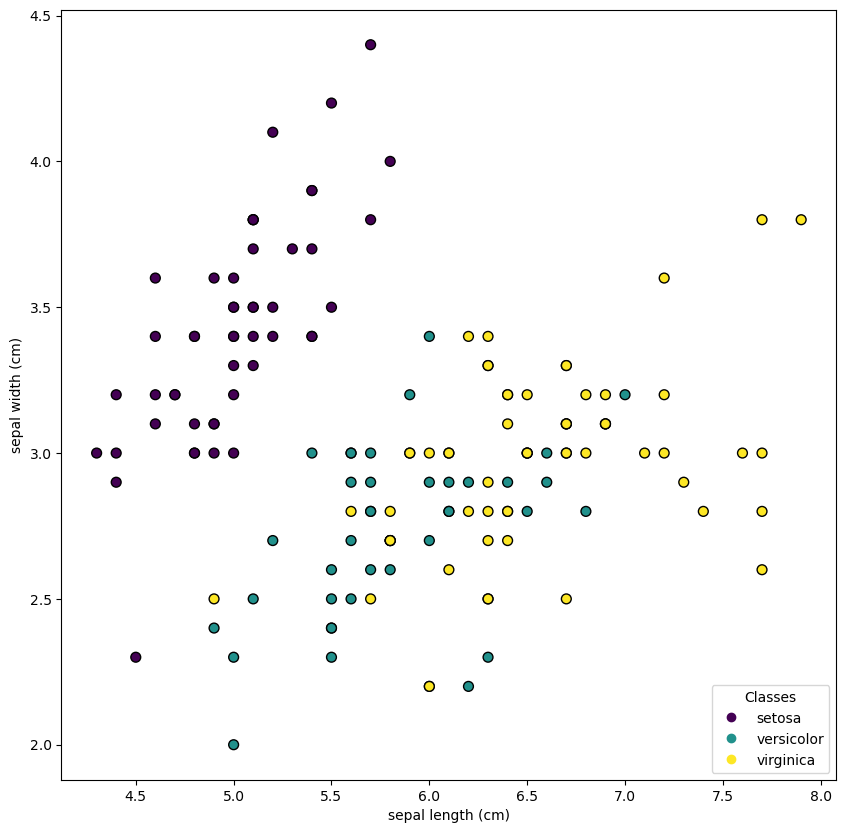

In [81]:
plt.figure(figsize=(10, 10))
scatter = plt.scatter(iris.data[:, 0], iris.data[:, 1], c = iris.target, s = 50, edgecolor = 'k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(scatter.legend_elements()[0], iris.target_names, loc = "lower right", 
           title = "Classes")
plt.show()

Dans le cadre de l’application du perceptron, nous ne considérons que les classes Setosa et Versicolor, étant donné que ces deux classes peuvent être séparées par une frontière linéaire, ce qui convient aux hypothèses du modèle.

In [82]:
mask = iris.target != 2

In [83]:
# On garde que deux classes
x = iris.data[mask]
y = iris.target[mask]

In [84]:
# Division de l'échantillon X et les classes t en deux echantillons aléatoire 
# d'entrainement et de test
X_train, X_test, Y_train, Y_test =  train_test_split(x, y, test_size = 0.2,  
                                                     random_state = 42, shuffle = True)

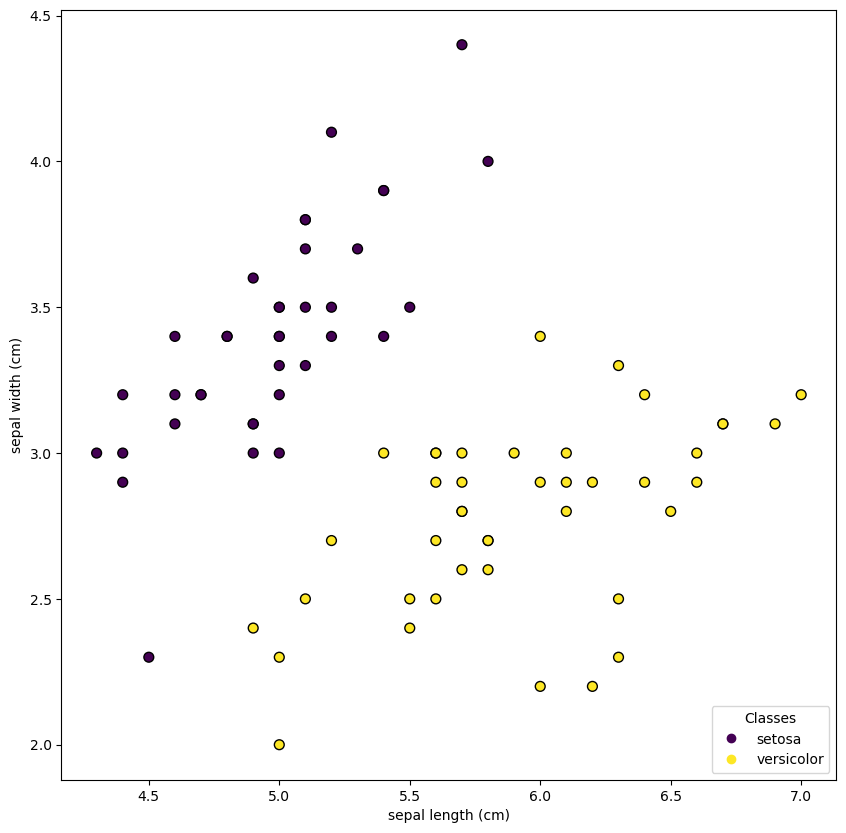

In [85]:
plt.figure(figsize=(10, 10))
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c = Y_train, s = 50, edgecolor = 'k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(scatter.legend_elements()[0], iris.target_names, loc = "lower right", 
           title = "Classes")
plt.show()

On défition les fonctions utilent pour la suite

In [86]:
# Définition de la fonction qui permet d'initialiser les paramètres du modèle 
def init(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn()
    return W, b

In [87]:
# Définition du model qui prend la fonction linéaire et la fonction d'activation
def mod(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z)) # fonction d'activation sigmoide
    return A

In [88]:
# Définition de la fonction de coût log loss
def l_loss(A, y):
    return -1 / len(y) * (np.sum(y * np.log(A) + (1 - y) * np.log(1 - A)))

In [89]:
# Définition de la fonction gradient pour la déscente de gradient
def grad(X, A, y):
    dW = 1/len(y) * np.dot(X.transpose(), A - y)
    db = 1/len(y) * np.sum(A - y)
    return dW, db

In [90]:
# Définition d'une fonction de mise à jour des paramètres
def update(dW, db, W, b, rate):
    W = W - rate * dW
    b = b - rate * db
    return W, b

In [91]:
def neuron(X, y, rate = 0.1, itermax = 1000):
    # initialisation des paramètres
    W, b = init(X)
    loss = []
    y = y.reshape(-1, 1) 
    
    for i in range(itermax):
        A = mod(X, W, b)
        loss.append(l_loss(A, y))
        dW, db = grad(X, A, y)
        W, b = update(dW, db, W, b, rate)
        
    return W, b, loss

In [92]:
W, b, loss = neuron(X_train, Y_train)

In [93]:
print("X", X_train.shape)
print("W", W.shape)
print("A", A.shape)
print("y", Y_train.shape)

X (80, 4)
W (4, 1)
A (80, 1)
y (80,)


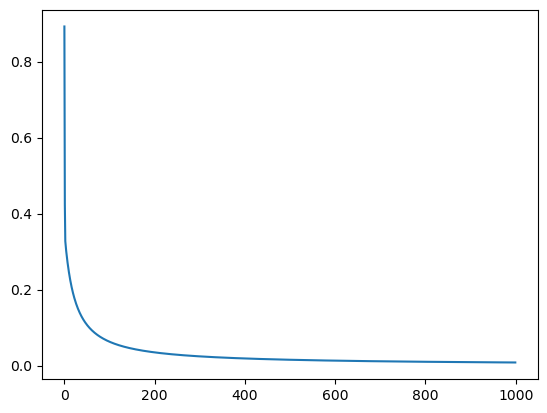

In [94]:
plt.plot(loss)
plt.show()

Dans cette section, nous procédons à l’évaluation des performances du modèle en mesurant sa précision de classification sur les ensembles d’apprentissage et de test, afin d’apprécier sa capacité de généralisation.

In [95]:
def pred(X, W, b):
    A = mod(X, W, b)
    return A >= 0.5

In [96]:
y_pred = pred(X_train, W, b)
print(accuracy_score(Y_train, y_pred))

1.0


Nous appliquons ensuite le modèle entraîné afin d’obtenir les prédictions sur l’échantillon de test et d’évaluer ses performances hors échantillon.

In [98]:
y_tpred = pred(X_test, W, b)
print(accuracy_score(Y_test, y_tpred))

1.0
